In [69]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from utils import ols, mse, rmse, mae, r_squared, adjusted_r_squared

In [70]:
seed = 0
df = sns.load_dataset('tips')
sns.set_theme(
  style='darkgrid',
)

In [71]:
from sklearn.model_selection import train_test_split


def produce_training_data(df):
  X = df[['total_bill']]
  y = df['tip'].to_numpy()

  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)

  assert X_train.shape[0] == y_train.shape[0], "X train's shape does not match the y train's shape"


  X_train = np.concat((np.ones(X_train.shape[0]).reshape(-1, 1), X_train), axis=1)
  X_test = np.concat((np.ones(X_test.shape[0]).reshape(-1, 1), X_test), axis=1)

  return X_train, X_test, y_train, y_test


In [72]:
X_train, X_test, y_train, y_test = produce_training_data(df)

weights = ols(X_train, y_train)
y_pred = X_test @ weights
residuals = y_test - y_pred

display(weights)
pd.DataFrame([{
  "MSE": mse(y_test, y_pred),
  "RMSE": rmse(y_test, y_pred), 
  "MAE": mae(y_test, y_pred), 
  "R2": r_squared(y_test, y_pred), 
  "Adjusted_R2": adjusted_r_squared(y_test, y_pred, X_test.shape[1] - 1),
}])

#NOTE: RMSE = 0.9 & MAE = 0.65 . which means our model have error of 65cents to 90cents on average
#NOTE: R2   = 0.59 . which means our model covers the 59% of tip variance.

array([1.02854395, 0.0968534 ])

,MSE,RMSE,MAE,R2,Adjusted_R2
0,0.821309,0.906261,0.656407,0.59069,0.581981


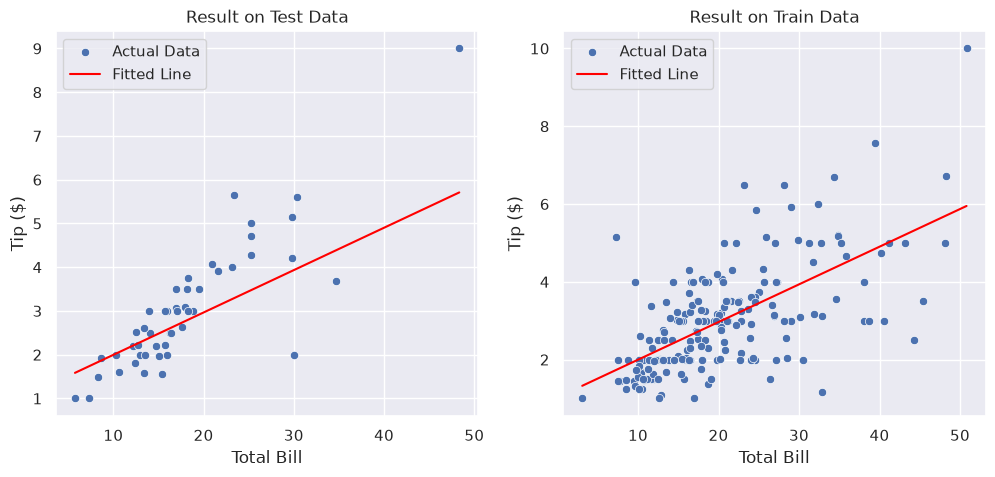

In [73]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(x=X_test[:, 1], y=y_test, label='Actual Data', ax=ax1)
sns.lineplot(x=X_test[:, 1], y=y_pred, color='red', label='Fitted Line', ax=ax1)
ax1.set(
    title='Result on Test Data',
    xlabel='Total Bill',
    ylabel='Tip ($)'
);

sns.scatterplot(x=X_train[:, 1], y=y_train, label='Actual Data', ax=ax2)
sns.lineplot(x=X_train[:, 1], y=X_train @ weights, color='red', label='Fitted Line', ax=ax2)
ax2.set(
    title='Result on Train Data',
    xlabel='Total Bill',
    ylabel='Tip ($)'
);

# ax.hlines()

<Axes: ylabel='Density'>

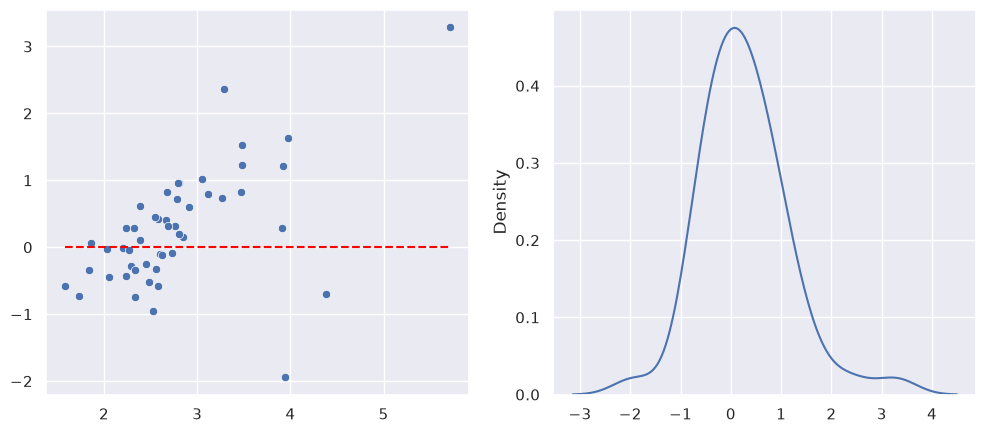

In [74]:
fig, (ax1 , ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax = sns.scatterplot(x=y_pred, y=residuals, ax=ax1)
ax.hlines(y=0, xmin=y_pred.min(), xmax=y_pred.max(), colors='red', linestyle='--')

sns.kdeplot(x=residuals, ax=ax2)

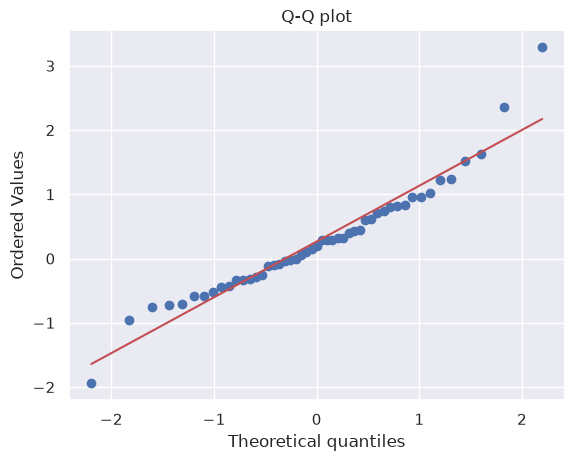

In [75]:
import scipy

fig, ax = plt.subplots()

scipy.stats.probplot(residuals.reshape(-1), plot=ax, fit=True, dist="norm")
ax.set_title('Q-Q plot')
plt.show()